# 深度循环神经网络（Deep RNN）


单层RNN存在问题：表达能力有限，难以同时建模复杂的短期和长期依赖，对复杂序列（如金融、语言）不够灵活。  

解决方法：像MLP一样堆叠多层RNN（加深网络）


深度RNN就是：在时间维度上递归，在层数维度上堆叠

结构特点

每个时间步 t，每一层都有自己的隐状态，信息在两个方向传播：

时间方向（横向）：
在同一层，
Hₜ⁽ˡ⁾ ← Hₜ₋₁⁽ˡ⁾，表示“记忆传递”

层间方向（纵向）：
在不同层，
Hₜ⁽ˡ⁾ ← Hₜ⁽ˡ⁻¹⁾，表示“特征抽象”

数学表达：

这个架构是由 :numref:`fig_deep_rnn`中描述了$L$个隐藏层构成。

假设在时间步$t$有一个小批量的输入数据
$\mathbf{X}_t \in \mathbb{R}^{n \times d}$
（样本数：$n$，每个样本中的输入数：$d$）。
同时，将$l^\mathrm{th}$隐藏层（$l=1,\ldots,L$）
的隐状态设为$\mathbf{H}_t^{(l)}  \in \mathbb{R}^{n \times h}$
（隐藏单元数：$h$），
输出层变量设为$\mathbf{O}_t \in \mathbb{R}^{n \times q}$
（输出数：$q$）。
设置$\mathbf{H}_t^{(0)} = \mathbf{X}_t$，
第$l$个隐藏层的隐状态使用激活函数$\phi_l$，则：

$$\mathbf{H}_t^{(l)} = \phi_l(\mathbf{H}_t^{(l-1)} \mathbf{W}_{xh}^{(l)} + \mathbf{H}_{t-1}^{(l)} \mathbf{W}_{hh}^{(l)}  + \mathbf{b}_h^{(l)}),$$

其中，权重$\mathbf{W}_{xh}^{(l)} \in \mathbb{R}^{h \times h}$，
$\mathbf{W}_{hh}^{(l)} \in \mathbb{R}^{h \times h}$和
偏置$\mathbf{b}_h^{(l)} \in \mathbb{R}^{1 \times h}$
都是第$l$个隐藏层的模型参数。

输出层仅基于第$l$个隐藏层最终的隐状态：

$$\mathbf{O}_t = \mathbf{H}_t^{(L)} \mathbf{W}_{hq} + \mathbf{b}_q,$$


可以看出前面层负责提取特征，最后一层负责输出。  

超参数：隐藏层数目$L$和隐藏单元数目$h$都是超参数。类似MLP中的层数和神经元数



简洁实现

许多逻辑细节在高级API中都是现成的

In [1]:
import torch
import re
import requests
from collections import Counter


url = "http://d2l-data.s3-accelerate.amazonaws.com/timemachine.txt"
file_path = "timemachine.txt"

response = requests.get(url)
with open(file_path, "wb") as f:
    f.write(response.content)


def read_time_machine():
    with open(file_path, "r") as f:
        lines = f.readlines()
    return [re.sub("[^A-Za-z]+", " ", line).strip().lower() for line in lines]

lines = read_time_machine()


tokens = [list(line) for line in lines]
corpus = [token for line in tokens for token in line]


class Vocab:
    def __init__(self, tokens):
        counter = Counter(tokens)
        self.idx_to_token = list(counter.keys())
        self.token_to_idx = {token: i for i, token in enumerate(self.idx_to_token)}

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, token):
        return self.token_to_idx[token]

vocab = Vocab(corpus)
corpus = [vocab[token] for token in corpus]


def load_data_time_machine(batch_size, num_steps):
    corpus_tensor = torch.tensor(corpus, dtype=torch.long)

    num_tokens = (len(corpus_tensor) // batch_size) * batch_size
    corpus_tensor = corpus_tensor[:num_tokens]

    corpus_tensor = corpus_tensor.reshape(batch_size, -1)
    num_batches = (corpus_tensor.shape[1] - 1) // num_steps

    data = []
    for i in range(0, num_batches * num_steps, num_steps):
        X = corpus_tensor[:, i:i + num_steps]
        Y = corpus_tensor[:, i + 1:i + num_steps + 1]
        data.append((X, Y))

    return data, vocab


batch_size, num_steps = 32, 35
train_iter, vocab = load_data_time_machine(batch_size, num_steps)

# 测试一下
for X, Y in train_iter:
    print(X.shape, Y.shape)
    break

torch.Size([32, 35]) torch.Size([32, 35])


选择超参数：

因为我们有不同的词元，所以输入和输出都选择相同数量，即vocab_size。 隐藏单元的数量仍然是 256 。 通过num_layers的值来设定隐藏层数。

In [2]:
import torch
from torch import nn
import torch.nn.functional as F

# 定义模型封装
class RNNModel(nn.Module):
    def __init__(self, rnn_layer, vocab_size):
        super().__init__()
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.num_hiddens = rnn_layer.hidden_size
        self.num_directions = 2 if rnn_layer.bidirectional else 1
        self.linear = nn.Linear(self.num_hiddens * self.num_directions, vocab_size)

    def forward(self, inputs, state):
        # inputs: (batch_size, num_steps)
        X = F.one_hot(inputs.T.long(), self.vocab_size).type(torch.float32)
        # X: (num_steps, batch_size, vocab_size)
        Y, state = self.rnn(X, state)
        # Y: (num_steps, batch_size, num_hiddens)
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state

    def begin_state(self, device, batch_size=1):
        if not isinstance(self.rnn, nn.LSTM):
            # GRU / RNN
            return torch.zeros((
                self.num_directions * self.rnn.num_layers,
                batch_size,
                self.num_hiddens
            ), device=device)
        else:
            # LSTM: 返回 (H, C)
            return (
                torch.zeros((
                    self.num_directions * self.rnn.num_layers,
                    batch_size,
                    self.num_hiddens
                ), device=device),
                torch.zeros((
                    self.num_directions * self.rnn.num_layers,
                    batch_size,
                    self.num_hiddens
                ), device=device)
            )






vocab_size, num_hiddens, num_layers = len(vocab), 256, 2
num_inputs = vocab_size
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lstm_layer = nn.LSTM(vocab_size, num_hiddens, num_layers)
model = RNNModel(lstm_layer, vocab_size).to(device)

训练预测

In [3]:
import torch
from torch import nn
import torch.nn.functional as F

class RNNModel(nn.Module):
    def __init__(self, rnn_layer, vocab_size):
        super().__init__()
        self.rnn = rnn_layer
        self.vocab_size = vocab_size
        self.num_hiddens = rnn_layer.hidden_size
        self.num_directions = 2 if rnn_layer.bidirectional else 1
        self.linear = nn.Linear(self.num_hiddens * self.num_directions, vocab_size)

    def forward(self, inputs, state):
        X = F.one_hot(inputs.T.long(), self.vocab_size).to(torch.float32)
        Y, state = self.rnn(X, state)
        output = self.linear(Y.reshape((-1, Y.shape[-1])))
        return output, state

    def begin_state(self, batch_size=1, device='cpu'):
        if isinstance(self.rnn, nn.LSTM):
            return (
                torch.zeros(
                    (self.num_directions * self.rnn.num_layers, batch_size, self.num_hiddens),
                    device=device
                ),
                torch.zeros(
                    (self.num_directions * self.rnn.num_layers, batch_size, self.num_hiddens),
                    device=device
                )
            )
        else:
            return torch.zeros(
                (self.num_directions * self.rnn.num_layers, batch_size, self.num_hiddens),
                device=device
            )

In [4]:
import torch

def grad_clipping(net, theta):
    if isinstance(net, torch.nn.Module):
        params = [p for p in net.parameters() if p.requires_grad]
    else:
        params = net.params

    norm = torch.sqrt(sum(torch.sum(p.grad ** 2) for p in params))
    if norm > theta:
        for param in params:
            param.grad[:] *= theta / norm

In [5]:
import time
import math
from torch import nn

def train_epoch_ch8(net, train_iter, loss, updater, device, use_random_iter):
    state = None
    start_time = time.time()
    metric = [0.0, 0]

    for X, Y in train_iter:
        if state is None or use_random_iter:
            state = net.begin_state(X.shape[0], device)
        else:
            if isinstance(state, tuple):
                state = tuple(s.detach() for s in state)
            else:
                state = state.detach()

        y = Y.T.reshape(-1)
        X, y = X.to(device), y.to(device)

        y_hat, state = net(X, state)
        l = loss(y_hat, y.long()).mean()

        if isinstance(updater, torch.optim.Optimizer):
            updater.zero_grad()
            l.backward()
            grad_clipping(net, 1)
            updater.step()
        else:
            l.backward()
            grad_clipping(net, 1)
            updater(batch_size=1)

        metric[0] += l.item() * y.numel()
        metric[1] += y.numel()

    return math.exp(metric[0] / metric[1]), metric[1] / (time.time() - start_time)

In [6]:
import matplotlib.pyplot as plt

def train_ch8(net, train_iter, vocab, lr, num_epochs, device,
              use_random_iter=False):
    loss = nn.CrossEntropyLoss()

    # 优化器
    if isinstance(net, nn.Module):
        updater = torch.optim.SGD(net.parameters(), lr=lr)
    else:
        def updater(batch_size):
            for param in net.params:
                param.data -= lr * param.grad / batch_size
                param.grad.zero_()

    ppl_list = []
    epoch_list = []

    for epoch in range(num_epochs):
        ppl, speed = train_epoch_ch8(
            net, train_iter, loss, updater, device, use_random_iter
        )

        if (epoch + 1) % 10 == 0:
            print(f'epoch {epoch+1}, ppl {ppl:.3f}')
            ppl_list.append(ppl)
            epoch_list.append(epoch + 1)

    print(f'最终困惑度 {ppl:.1f}, {speed:.1f} tokens/sec')

    # 画图
    plt.plot(epoch_list, ppl_list)
    plt.xlabel('epoch')
    plt.ylabel('perplexity')
    plt.grid()
    plt.show()

In [7]:
import inspect
print(inspect.signature(RNNModel.begin_state))

(self, batch_size=1, device='cpu')


In [8]:
import torch
from torch import nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

vocab_size, num_hiddens, num_layers = len(vocab), 256, 2

lstm_layer = nn.LSTM(vocab_size, num_hiddens, num_layers)
model = RNNModel(lstm_layer, vocab_size)
model = model.to(device)

cuda


epoch 10, ppl 7.107
epoch 20, ppl 4.570
epoch 30, ppl 3.411
epoch 40, ppl 2.641
epoch 50, ppl 2.137
epoch 60, ppl 1.826
epoch 70, ppl 1.602
epoch 80, ppl 1.443
epoch 90, ppl 1.329
epoch 100, ppl 1.241
epoch 110, ppl 1.155
epoch 120, ppl 1.220
epoch 130, ppl 1.028
epoch 140, ppl 1.011
epoch 150, ppl 1.007
epoch 160, ppl 1.367
epoch 170, ppl 1.027
epoch 180, ppl 1.008
epoch 190, ppl 1.005
epoch 200, ppl 1.004
epoch 210, ppl 1.223
epoch 220, ppl 1.077
epoch 230, ppl 1.008
epoch 240, ppl 1.005
epoch 250, ppl 1.003
epoch 260, ppl 1.003
epoch 270, ppl 1.002
epoch 280, ppl 1.002
epoch 290, ppl 1.002
epoch 300, ppl 1.001
epoch 310, ppl 1.001
epoch 320, ppl 1.001
epoch 330, ppl 1.001
epoch 340, ppl 1.001
epoch 350, ppl 1.001
epoch 360, ppl 1.001
epoch 370, ppl 1.001
epoch 380, ppl 1.001
epoch 390, ppl 1.001
epoch 400, ppl 1.001
epoch 410, ppl 1.001
epoch 420, ppl 1.001
epoch 430, ppl 1.001
epoch 440, ppl 1.001
epoch 450, ppl 1.001
epoch 460, ppl 1.001
epoch 470, ppl 1.001
epoch 480, ppl 1.001
e

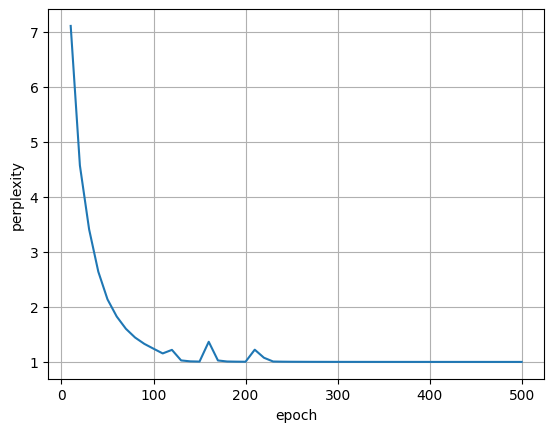

In [9]:
num_epochs, lr = 500, 2
train_ch8(model, train_iter, vocab, lr*1.0, num_epochs, device)